Import library

In [1]:
import os
import re
import cv2
import torch
import pandas as pd
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Check CUDA
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.empty_cache()
device

'cuda'

In [3]:
weights_path = os.path.join("..", "..", "..", "weights", "seed_count", "yolov8_seed_count_best.pt")
data_path = os.path.join("..", "..", "..", "sample_data", "raw_spread_seeds_lab")
weights_path, data_path

('..\\..\\..\\weights\\seed_count\\yolov8_seed_count_best.pt',
 '..\\..\\..\\sample_data\\raw_spread_seeds_lab')

Total seeds: 2449


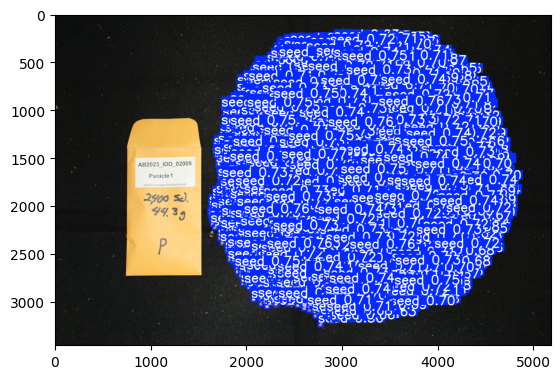

In [4]:
sample_image = os.path.join(data_path, '2005', '2005_1.jpg')
model = YOLO(weights_path)  # load a custom model
results = model(sample_image, max_det = 3000, conf = 0.1, verbose=False)
fig = plt.figure()
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
boxes_fr = results[0].boxes.xywh.cpu().numpy()
print("Total seeds:", len(boxes_fr))
plt.imshow(detect_img)
plt.show()

## Dataframe created read the folders and images and put in the dataframe

In [5]:
df = pd.DataFrame(columns=['id', 'image_name', 'rep', 'seed_counts'])
data = []
for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    r = 1
    images = [f for f in files if (f.lower().endswith('JPG'.lower()))] # filter images
    if not images:
        continue # if there are no image in the folder, then continue loop
    for file in files:
        if (file.lower().endswith('JPG'.lower())):
            if '_1' in file:
                r = 1
            elif '_2' in file:
                r = 2
            elif '_3' in file:
                r = 3
            elif '_4' in file:
                r = 4
            data.append([folder_name, file, r])

df[['id', 'image_name', 'rep']] = data
df

,id,image_name,rep,seed_counts
0,2005,2005_1.JPG,1,NaN
1,2005,2005_2.JPG,2,NaN
2,2005,2005_3.JPG,3,NaN
3,2005,2005_4.JPG,4,NaN
4,2009,2009_1.JPG,1,NaN
5,2009,2009_2.JPG,2,NaN
6,2009,2009_3.JPG,3,NaN
7,2009,2009_4.JPG,4,NaN
8,2013,2013_1.JPG,1,NaN
9,2013,2013_2.JPG,2,NaN


In [6]:
# Initialize an empty list to store results
output_dir = r'predicted_outputs'
conf_val = 0.1

# Make a pandas dataframe
for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    if folder_name == os.path.basename(data_path):
        continue
    # Create a corresponding output folder for this subfolder
    folder_output_dir = os.path.join(output_dir, folder_name)
    os.makedirs(folder_output_dir, exist_ok=True)
    image_folder_path = os.path.join(data_path, folder_name)
    images = [f for f in files if (f.lower().endswith('JPG'.lower()))] # filter images
    if not images:
        continue # if there are no image in the folder, then continue loop
    images.sort()
    for idx, img in enumerate(images):
        img_path = os.path.join(image_folder_path, img)

        # Perform inference
        result = model(img_path, max_det = 3000, conf = conf_val, show_labels=False,show_conf=False)
        
        # Extract the bounding boxes
        boxes = result[0].boxes.xywh.cpu().numpy()  # Convert tensor to NumPy array for compatibility
        num_boxes = len(boxes)
        df.loc[(df['id']==folder_name) & (df['image_name']==img), 'seed_counts'] = num_boxes
        
        # Draw the bounding boxes on the image
        detect_img = result[0].plot()
        
        # Save the image with bounding boxes
        output_image_path = os.path.join(folder_output_dir, img)
        cv2.imwrite(output_image_path, detect_img)
df

,id,image_name,rep,seed_counts
0,2005,2005_1.JPG,1,2449
1,2005,2005_2.JPG,2,1611
2,2005,2005_3.JPG,3,1917
3,2005,2005_4.JPG,4,2046
4,2009,2009_1.JPG,1,676
5,2009,2009_2.JPG,2,996
6,2009,2009_3.JPG,3,934
7,2009,2009_4.JPG,4,1468
8,2013,2013_1.JPG,1,2086
9,2013,2013_2.JPG,2,2794


In [7]:
df.to_csv('predicted_panicle_seed_counts_spread_yolov8.csv', index=False)